In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch 
import torch.nn as nn
from torch import nn

In [34]:
weight = 0.6
bias = 0.35

start = 0
end = 1
step = 0.02

X = torch.arange(start,end,step)
y = weight * X + bias

X[:10],y[:10]

(tensor([0.0000, 0.0200, 0.0400, 0.0600, 0.0800, 0.1000, 0.1200, 0.1400, 0.1600,
         0.1800]),
 tensor([0.3500, 0.3620, 0.3740, 0.3860, 0.3980, 0.4100, 0.4220, 0.4340, 0.4460,
         0.4580]))

In [35]:
len(X),len(y)

(50, 50)

In [36]:
#Split the data
train_split = int(0.8 * len(X))
X_train,y_train = X[:train_split],y[:train_split]
X_test,y_test = X[train_split:],y[train_split:]

len(X_train),len(y_train),len(X_test),len(y_test)

(40, 40, 10, 10)

In [37]:
def plot_predictions(train_data = X_train,
                     train_label = y_train,
                     test_data = X_test,
                     test_label = y_test,
                     predictions = None):
    # Plotting the predictions
    plt.figure(figsize=(10,6))
    plt.scatter(train_data,train_label,color = 'blue',label = 'Training Data')
    plt.scatter(test_data,test_label,color = 'green',label = 'Testing Data')
    
    if predictions is not None:
        plt.scatter(test_data,predictions,color = 'red',label = 'Predictions')
        
    plt.legend()
    plt.show()

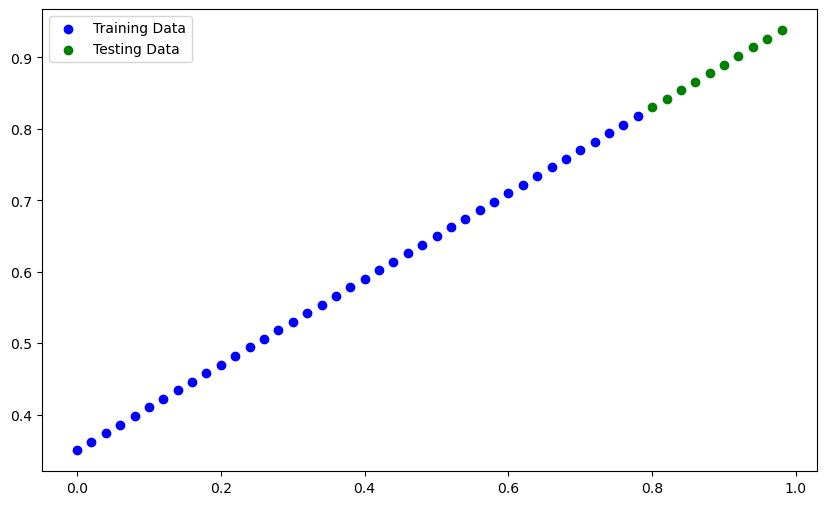

In [38]:
plot_predictions()

In [39]:
class LRMODEL(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float))
        
    def forward(self,x:torch.Tensor)->torch.Tensor:
        return self.weights * x + self.bias

In [40]:
torch.manual_seed(42)
model_1 = LRMODEL()
model_1

LRMODEL()

In [41]:
list(model_1.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [42]:
model_1.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [43]:
with torch.inference_mode():
    # Initialize the model
    y_pred = model_1(X_test)
y_pred

tensor([0.3982, 0.4049, 0.4116, 0.4184, 0.4251, 0.4318, 0.4386, 0.4453, 0.4520,
        0.4588])

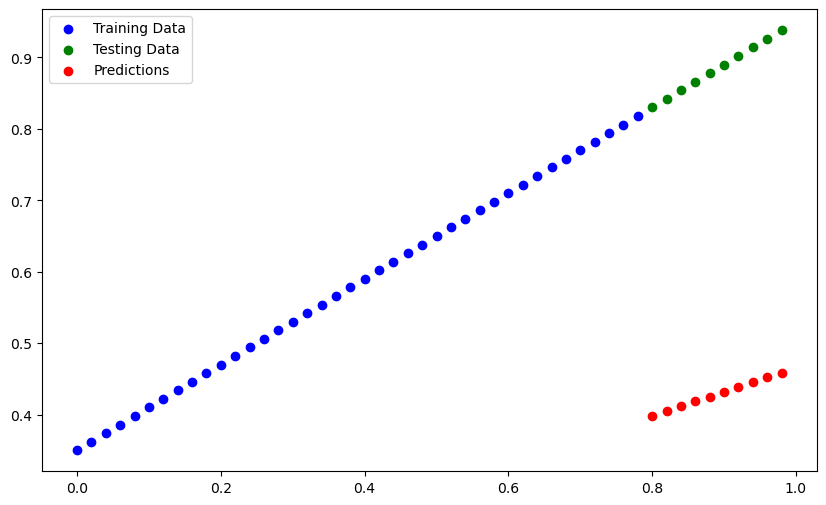

In [44]:
plot_predictions(predictions=y_pred)

In [45]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model_1.parameters(),lr = 0.01)


In [46]:
epochs = 100

#forward pass
for epoch in range(epochs):
    y_pred = model_1(X_train)
    loss = loss_fn(y_pred,y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
#evaluate

    model_1.eval()
    with torch.inference_mode():
        y_pred_test = model_1(X_test)
        test_loss = loss_fn(y_pred_test,y_test)
        
        if epoch % 10 == 0:
            print(f"Epoch: {epoch} | Test loss: {test_loss.item():.4f} | Loss: {loss.item():.4f}")

            
        print(model_1.state_dict)
    


Epoch: 0 | Test loss: 0.4421 | Loss: 0.3239
<bound method Module.state_dict of LRMODEL()>
<bound method Module.state_dict of LRMODEL()>
<bound method Module.state_dict of LRMODEL()>
<bound method Module.state_dict of LRMODEL()>
<bound method Module.state_dict of LRMODEL()>
<bound method Module.state_dict of LRMODEL()>
<bound method Module.state_dict of LRMODEL()>
<bound method Module.state_dict of LRMODEL()>
<bound method Module.state_dict of LRMODEL()>
<bound method Module.state_dict of LRMODEL()>
Epoch: 10 | Test loss: 0.3074 | Loss: 0.2087
<bound method Module.state_dict of LRMODEL()>
<bound method Module.state_dict of LRMODEL()>
<bound method Module.state_dict of LRMODEL()>
<bound method Module.state_dict of LRMODEL()>
<bound method Module.state_dict of LRMODEL()>
<bound method Module.state_dict of LRMODEL()>
<bound method Module.state_dict of LRMODEL()>
<bound method Module.state_dict of LRMODEL()>
<bound method Module.state_dict of LRMODEL()>
<bound method Module.state_dict of LR

In [47]:
with torch.inference_mode():
    y_pred_newest = model_1(X_test)

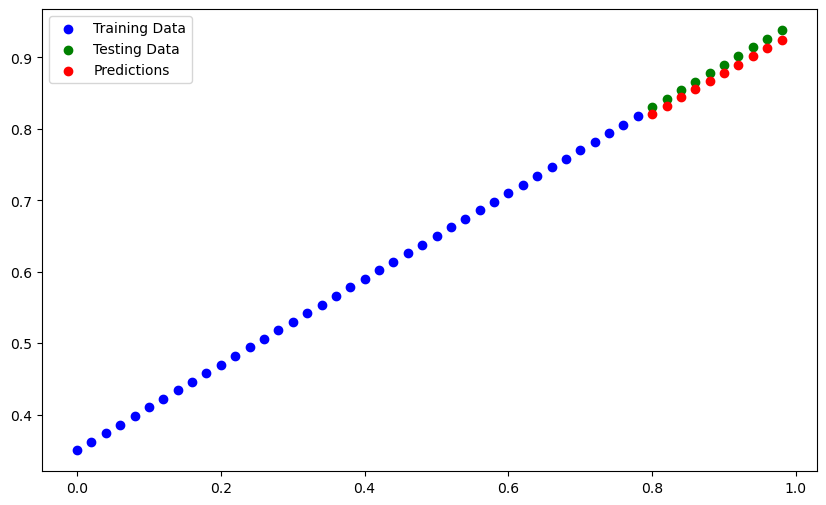

In [48]:
plot_predictions(predictions=y_pred_newest)

In [49]:
model_1.state_dict()

OrderedDict([('weights', tensor([0.5758])), ('bias', tensor([0.3603]))])

In [50]:
from pathlib import Path

In [51]:
MODEL_PATH = Path("modelss")
MODEL_PATH.mkdir(exist_ok=True,parents=True)

MODEL_NAME = "01-Pytorch.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

MODEL_SAVE_PATH

PosixPath('modelss/01-Pytorch.pth')

In [52]:
print(f"Saving Model to : {MODEL_SAVE_PATH}")
torch.save(obj = model_1.state_dict(),f = MODEL_SAVE_PATH)

Saving Model to : modelss/01-Pytorch.pth


In [53]:
torch.load(f = MODEL_SAVE_PATH,weights_only=True)

OrderedDict([('weights', tensor([0.5758])), ('bias', tensor([0.3603]))])

In [54]:
loaded_model_0 = LRMODEL()
loaded_model_0.state_dict(torch.load(f=MODEL_SAVE_PATH,weights_only=True))

/var/folders/89/hlf99zq566v5gtf30kyt2gp40000gn/T/ipykernel_52885/1535769590.py:2: FutureWarning: Positional args are being deprecated, use kwargs instead. Refer to https://pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.state_dict for details.
  loaded_model_0.state_dict(torch.load(f=MODEL_SAVE_PATH,weights_only=True))


OrderedDict([('weights', tensor([0.2345])), ('bias', tensor([0.2303]))])

Device Agnostic code - means switching to a GPU instead of a CPU


In [55]:
device = 'cuda' if torch.cuda.is_available() else "cpu"
print(f"Device Used:{device}")

Device Used:cpu


In [56]:
next(model_1.parameters()).device

device(type='cpu')

In [57]:
print("---------------")

---------------


In [58]:
weights = 0.7
bias = 0.3


start = 0
end = 1
step = 0.02

X = torch.arange(start,end,step)
y = weights * X + bias

X[:10],y[:10]

(tensor([0.0000, 0.0200, 0.0400, 0.0600, 0.0800, 0.1000, 0.1200, 0.1400, 0.1600,
         0.1800]),
 tensor([0.3000, 0.3140, 0.3280, 0.3420, 0.3560, 0.3700, 0.3840, 0.3980, 0.4120,
         0.4260]))

In [59]:
len(X),len(y)

(50, 50)